Initial Put Price = 27.098959883059933
Delta = -0.6086744776753927
Gamma = 0.009502255374008145
Theta = -26.46624019362534
Stock position M * delta = -60.867447767539275

----- Loss Distribution Summary -----

Full Loss:
Mean = 1.2588491166097446
Std  = 154.9089907085451
5%   = -108.99760633474703
95%  = 305.8428425205155
99%  = 608.2930426547616

Linearized Loss:
Value = -105.02476267311643

Quadratic Loss:
Mean = 0.8014354324053325
Std  = 149.35462181424694
5%   = -104.61369286019378
95%  = 301.14942819156624
99%  = 595.7119561969505


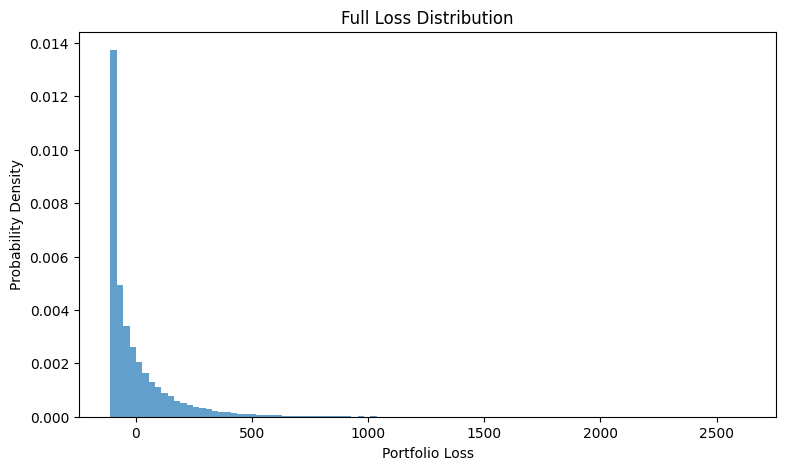

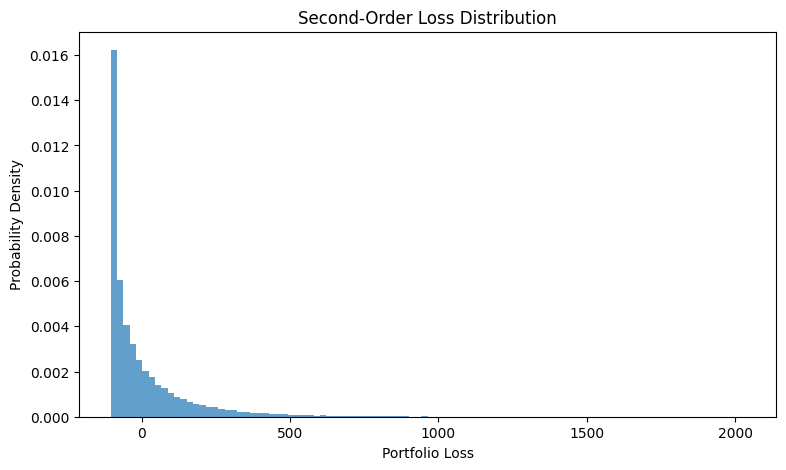

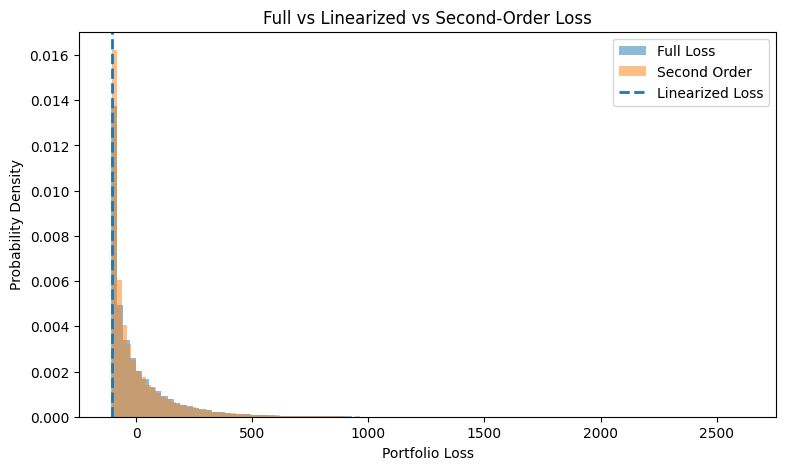

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# 1. Parameters
# ============================================================

mu = 0.16905
sigma = 0.4907
r = 0.0011888

t = 0.0
T = 0.291667
Delta_t = 10 / 252

S0 = 152.51
K = 170
M = 100

N_sim = 100_000

np.random.seed(42)


# ============================================================
# 2. Black-Scholes Put Price
# ============================================================

def bs_put_price(t, S, T, K, r, sigma):
    tau = T - t

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    put_price = (
        S * (norm.cdf(d1) - 1)
        + K * np.exp(-r * tau) * (1 - norm.cdf(d2))
    )

    return put_price


# ============================================================
# 3. Delta, Gamma, Theta for the Put
# ============================================================

def put_greeks(t, S, T, K, r, sigma):
    tau = T - t

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    # Put delta
    delta = norm.cdf(d1) - 1

    # Put gamma
    gamma = norm.pdf(d1) / (
        S * sigma * np.sqrt(tau)
    )

    # Put theta
    theta = (
        -sigma * S * norm.pdf(d1)
        / (2 * np.sqrt(tau))
        + r * K * np.exp(-r * tau)
        * (1 - norm.cdf(d2))
    )

    return delta, gamma, theta


# ============================================================
# 4. Initial option price and Greeks
# ============================================================

P0 = bs_put_price(
    t, S0, T, K, r, sigma
)

delta0, gamma0, theta0 = put_greeks(
    t, S0, T, K, r, sigma
)

# lambda is fixed over [t, t + Delta_t]
lam = delta0

print("Initial Put Price =", P0)
print("Delta =", delta0)
print("Gamma =", gamma0)
print("Theta =", theta0)
print("Stock position M * delta =", M * delta0)


# ============================================================
# 5. Simulate 10-day log returns under physical measure P
#
# X ~ Normal(
#       (mu - 0.5 sigma^2) Delta_t,
#       sigma^2 Delta_t
#     )
# ============================================================

Z = np.random.normal(
    0,
    1,
    N_sim
)

X = (
    (mu - 0.5 * sigma**2) * Delta_t
    + sigma * np.sqrt(Delta_t) * Z
)


# Future stock prices
S_future = S0 * np.exp(X)


# ============================================================
# 6. FULL LOSS OPERATOR
#
# L_full =
# -M [
#     lambda S0 (e^X - 1)
#     - (P_future - P0)
#    ]
# ============================================================

P_future = bs_put_price(
    t + Delta_t,
    S_future,
    T,
    K,
    r,
    sigma
)

L_full = -M * (
    lam * S0 * (np.exp(X) - 1)
    - (P_future - P0)
)


# ============================================================
# 7. LINEARIZED LOSS OPERATOR
#
# Because lambda = delta,
# the first-order stock term cancels:
#
# L_linear = M * theta * Delta_t
# ============================================================

L_linear_value = (
    M * theta0 * Delta_t
)

L_linear = np.full(
    N_sim,
    L_linear_value
)


# ============================================================
# 8. SECOND-ORDER LOSS OPERATOR
#
# L_quad =
# M theta Delta_t
# + 0.5 M gamma S0^2 X^2
# ============================================================

L_quad = (
    M * theta0 * Delta_t
    + 0.5
    * M
    * gamma0
    * S0**2
    * X**2
)


# ============================================================
# 9. Summary Statistics
# ============================================================

print("\n----- Loss Distribution Summary -----")

print("\nFull Loss:")
print("Mean =", np.mean(L_full))
print("Std  =", np.std(L_full))
print("5%   =", np.percentile(L_full, 5))
print("95%  =", np.percentile(L_full, 95))
print("99%  =", np.percentile(L_full, 99))

print("\nLinearized Loss:")
print("Value =", L_linear_value)

print("\nQuadratic Loss:")
print("Mean =", np.mean(L_quad))
print("Std  =", np.std(L_quad))
print("5%   =", np.percentile(L_quad, 5))
print("95%  =", np.percentile(L_quad, 95))
print("99%  =", np.percentile(L_quad, 99))


# ============================================================
# 10. Histogram: Full Loss
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    L_full,
    bins=100,
    density=True,
    alpha=0.7
)

plt.xlabel("Portfolio Loss")
plt.ylabel("Probability Density")
plt.title("Full Loss Distribution")

plt.show()


# ============================================================
# 11. Histogram: Second-Order Loss
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    L_quad,
    bins=100,
    density=True,
    alpha=0.7
)

plt.xlabel("Portfolio Loss")
plt.ylabel("Probability Density")
plt.title("Second-Order Loss Distribution")

plt.show()


# ============================================================
# 12. Compare Full vs Quadratic
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    L_full,
    bins=100,
    density=True,
    alpha=0.5,
    label="Full Loss"
)

plt.hist(
    L_quad,
    bins=100,
    density=True,
    alpha=0.5,
    label="Second Order"
)

plt.axvline(
    L_linear_value,
    linestyle="--",
    linewidth=2,
    label="Linearized Loss"
)

plt.xlabel("Portfolio Loss")
plt.ylabel("Probability Density")
plt.title("Full vs Linearized vs Second-Order Loss")

plt.legend()
plt.show()